## IMPORATATION OF NECESSARY LIBRARY

In [121]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid" , rc={"grid.linestyle":"--" , "grid.color":"black"})

In [122]:
data = pd.read_csv("../data/raw/HealthConnect_Appointment_Data.csv")
print(data.shape)
print(f" That is {data.shape[0]} Rows and {data.shape[1]} Columns")
data.head()

(5000, 18)
 That is 5000 Rows and 18 Columns


,appointment_id,patient_id,gender,age,age_group,appointment_type,booking_date,appointment_date,appointment_day,appointment_time,booking_lead_days,previous_appointments,previous_no_shows,reminder_sent,reminder_channel,distance_to_clinic_km,waiting_time_minutes,appointment_outcome
0,HC-00001,P-1613,Female,39,35-44,Follow-up,2/6/2025,2/18/2025,Tuesday,Afternoon,12,2,0,Yes,WhatsApp,19.3,29.0,No-Show
1,HC-00002,P-0813,Male,31,25-34,Specialist Consultation,2/25/2026,2/27/2026,Friday,Morning,2,6,0,Yes,SMS,14.3,42.0,Attended
2,HC-00003,P-1366,Female,50,45-54,General Consultation,11/16/2025,12/24/2025,Wednesday,Morning,38,5,1,Yes,SMS,11.4,11.0,No-Show
3,HC-00004,P-1031,Male,59,55-64,Follow-up,7/18/2025,8/28/2025,Thursday,Evening,41,3,1,Yes,SMS,7.4,35.0,Attended
4,HC-00005,P-1458,Female,34,25-34,Follow-up,7/9/2025,8/25/2025,Monday,Afternoon,47,3,1,Yes,Email,5.6,27.0,No-Show


In [123]:
print(data.info())
print("\n ################### SUMMARY ##################")
print(f" Numerical data types \n {data.select_dtypes(include="number").columns.to_list()} \n")
print(f"Categorical data types \n {data.select_dtypes(include="object").columns.to_list()}")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   appointment_id         5000 non-null   object 
 1   patient_id             5000 non-null   object 
 2   gender                 5000 non-null   object 
 3   age                    5000 non-null   int64  
 4   age_group              5000 non-null   object 
 5   appointment_type       5000 non-null   object 
 6   booking_date           5000 non-null   object 
 7   appointment_date       5000 non-null   object 
 8   appointment_day        5000 non-null   object 
 9   appointment_time       5000 non-null   object 
 10  booking_lead_days      5000 non-null   int64  
 11  previous_appointments  5000 non-null   int64  
 12  previous_no_shows      5000 non-null   int64  
 13  reminder_sent          5000 non-null   object 
 14  reminder_channel       3634 non-null   object 
 15  dist

## Missing values 

In [124]:
miss = data.isnull().sum()
miss = miss[miss>0]
print(f"Total missing values: {data.isnull().sum().sum()}\n")
print(miss)

Total missing values: 1516

reminder_channel         1366
distance_to_clinic_km      90
waiting_time_minutes       60
dtype: int64


## Visualization

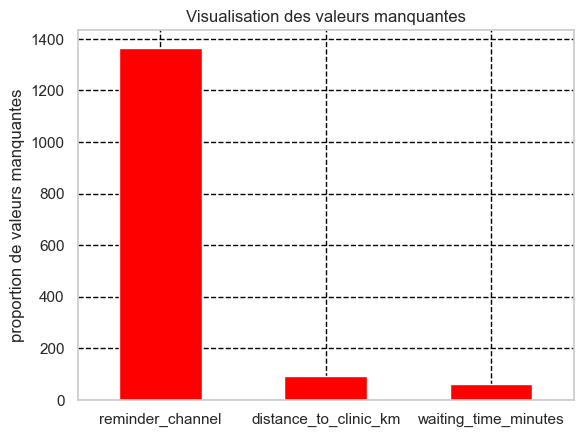

In [125]:
miss.plot(kind="bar",color="red" )
plt.ylabel("proportion of missing values")
plt.xticks(rotation=0)
plt.title("Missing Values Visualization")
plt.show()

## Duplicates

In [126]:
double = data.duplicated().sum()
if double is None:
    print("The dataset contains no duplicates")
else:
    print(f"Total number of duplicates: {double}")

Total number of duplicates: 0


## STATISTICAL SUMMRY FOR DATASETS

In [127]:
data.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
age,5000.0,48.79,18.14,18.0,33.0,49.0,64.0,80.0
booking_lead_days,5000.0,29.64,17.40,0.0,15.0,30.0,45.0,60.0
previous_appointments,5000.0,3.01,1.74,0.0,2.0,3.0,4.0,11.0
previous_no_shows,5000.0,0.54,0.75,0.0,0.0,0.0,1.0,5.0
distance_to_clinic_km,4910.0,10.11,6.59,0.5,5.3,8.7,13.5,45.0
waiting_time_minutes,4940.0,24.19,10.86,2.0,17.0,24.0,32.0,68.0


In [128]:
data.describe(include="object").T

,count,unique,top,freq
appointment_id,5000,5000,HC-05000,1
patient_id,5000,1696,P-1742,9
gender,5000,3,Female,2488
age_group,5000,6,65+,1241
appointment_type,5000,4,General Consultation,2086
booking_date,5000,593,8/24/2025,20
appointment_date,5000,545,3/14/2026,18
appointment_day,5000,7,Wednesday,737
appointment_time,5000,3,Morning,2227
reminder_sent,5000,2,Yes,3634


## UNIVARIATE ANALYSIS

## Target

In [129]:
target =  data["appointment_outcome"].value_counts(normalize=True)
target

appointment_outcome
No-Show      0.4846
Attended     0.4628
Cancelled    0.0526
Name: proportion, dtype: float64

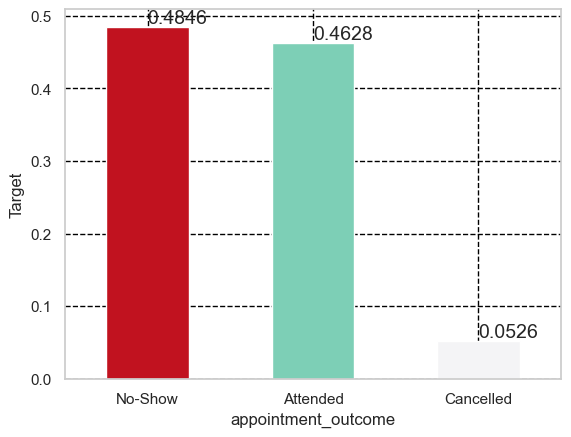

In [130]:
target.plot(kind="bar" , color=["#c1121f" ,"#7dcfb6"  , "#f4f4f6" ])
plt.ylabel("Target")
plt.xticks(rotation=0)
for index , val in enumerate(target):
    plt.text(index , val + 0.005
             , str(val), fontsize=14 , )
plt.show()

## NUMERICAL FEATURES 

In [131]:
num_features = data.select_dtypes(include="number").columns.to_list()
num_features

['age',
 'booking_lead_days',
 'previous_appointments',
 'previous_no_shows',
 'distance_to_clinic_km',
 'waiting_time_minutes']

In [132]:
print(data['previous_no_shows'].value_counts())
print(" \n previous_no_shows are evidently numerical types but it's contains just 6 value so we prefer to analyze it like categorical columns")

previous_no_shows
0    2921
1    1548
2     438
3      78
4      12
5       3
Name: count, dtype: int64
 
 previous_no_shows are evidently numerical types but it's contains just 6 value so we prefer to analyze it like categorical columns


In [133]:
num_features.remove('previous_no_shows')

In [134]:
num_features

['age',
 'booking_lead_days',
 'previous_appointments',
 'distance_to_clinic_km',
 'waiting_time_minutes']

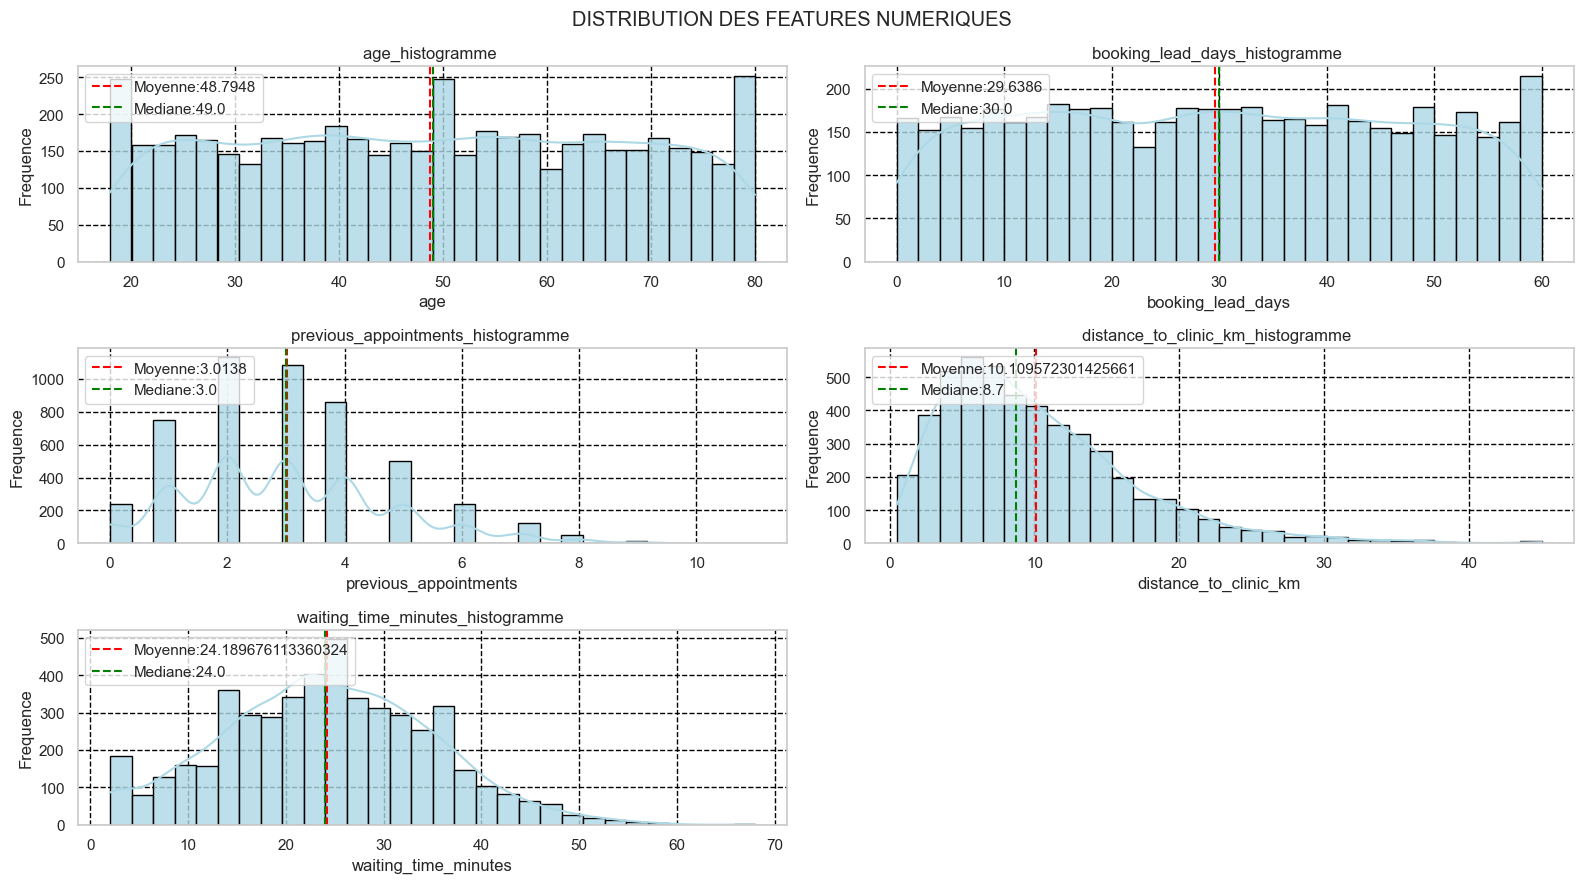

In [135]:
fig ,ax = plt.subplots(3,2, figsize=(16,9))
ax = ax.flatten()
for index, val in enumerate(num_features):
 sns.histplot(data=data , bins=30, x=val , edgecolor="black" , color="lightblue" , alpha=0.8 , kde=True , ax=ax[index] )
 ax[index].axvline(data[val].mean() , linestyle="--" , color="red", label=f"Mean:{data[val].mean() }")
 ax[index].axvline(data[val].median() , linestyle="--" , color="green", label=f"Median:{data[val].median() }")
 ax[index].set(title=f"{val}_histogram ", ylabel="Frequency" )
 ax[index].legend(loc="upper left")
for i in range( len(num_features) , len(ax)):
    fig.delaxes(ax[i])
plt.suptitle("DISTRIBUTION OF NUMERICAL FEATURES")
plt.tight_layout()
plt.savefig("../image/UNIVARIATE/histplot_univariate.png")
plt.show()

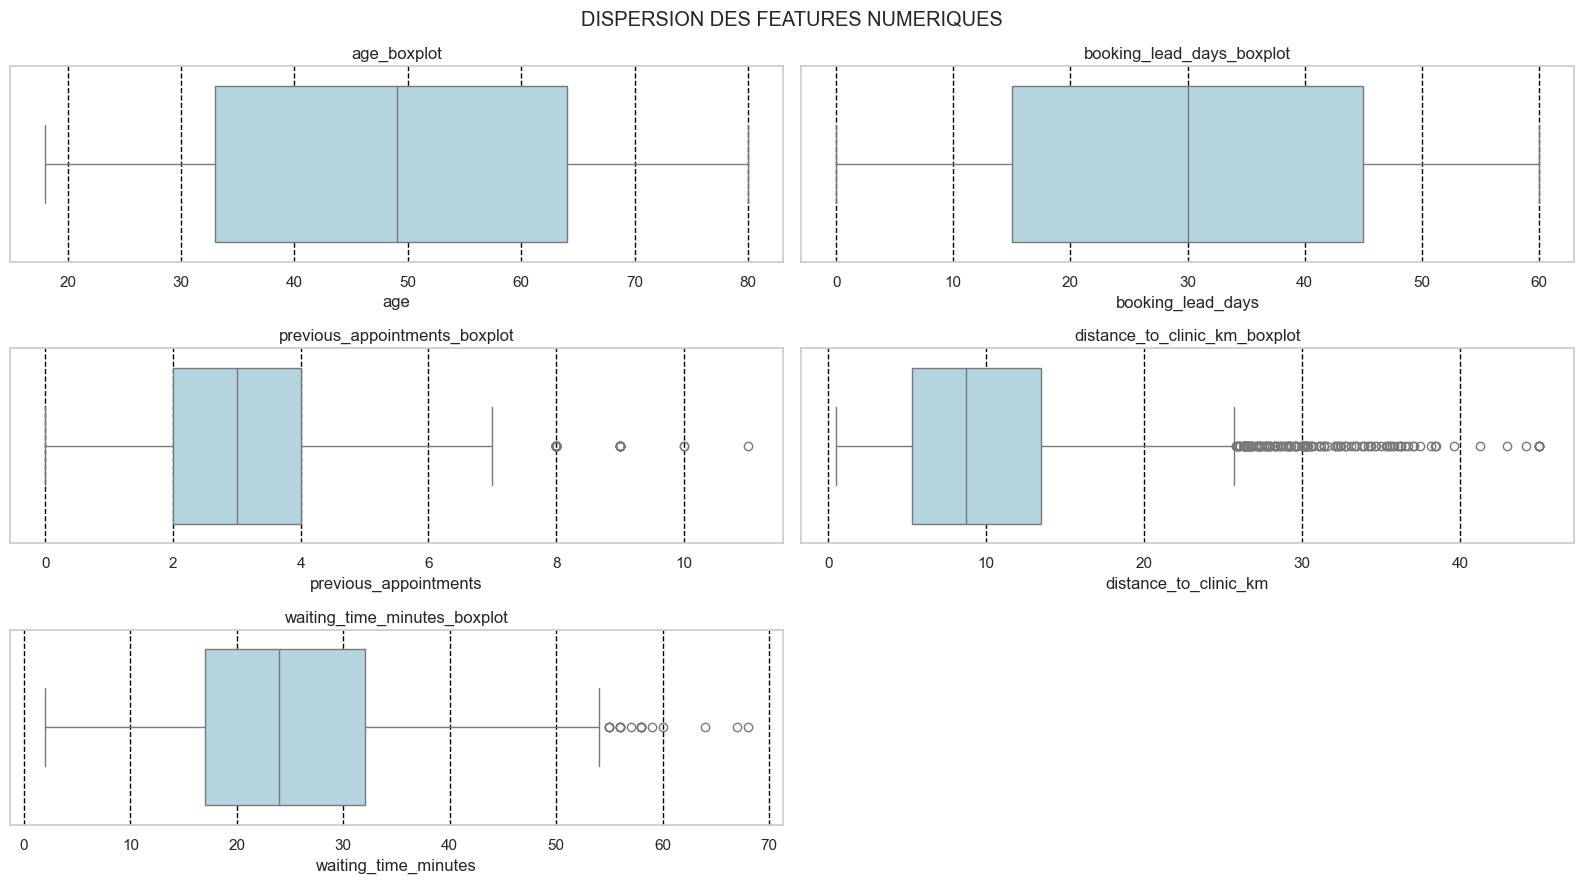

In [136]:
fig ,ax = plt.subplots(3,2, figsize=(16,9))
ax = ax.flatten()
for index, val in enumerate(num_features):
 sns.boxplot(data=data , x=val ,  color="lightblue", ax=ax[index] )
 ax[index].set(title=f"{val}_boxplot" )
for i in range( len(num_features) , len(ax)):
    fig.delaxes(ax[i])
plt.suptitle("DISPERSION OF NUMERICAL FEATURES")
plt.tight_layout()
plt.savefig("../image/UNIVARIATE/boxplot_univariate.png")
plt.show()

## CATEGORICAL FEATURES

In [137]:
category = data.select_dtypes(include="object").columns.to_list()
category

['appointment_id',
 'patient_id',
 'gender',
 'age_group',
 'appointment_type',
 'booking_date',
 'appointment_date',
 'appointment_day',
 'appointment_time',
 'reminder_sent',
 'reminder_channel',
 'appointment_outcome']

In [138]:
## We remove 'appointment_id','patient_id' because it's add zero , they have not predictions worth 

## We discover an important information about dataset , we have 02 colonnes that contains date , but python interpret that like string , to change that comportement we have to transform 
## that columns in datetime object to best extraction of information

In [139]:
for val in ['appointment_id','patient_id','booking_date', 'appointment_date'] :
     if val in category:
        category.remove(val)
category

['gender',
 'age_group',
 'appointment_type',
 'appointment_day',
 'appointment_time',
 'reminder_sent',
 'reminder_channel',
 'appointment_outcome']

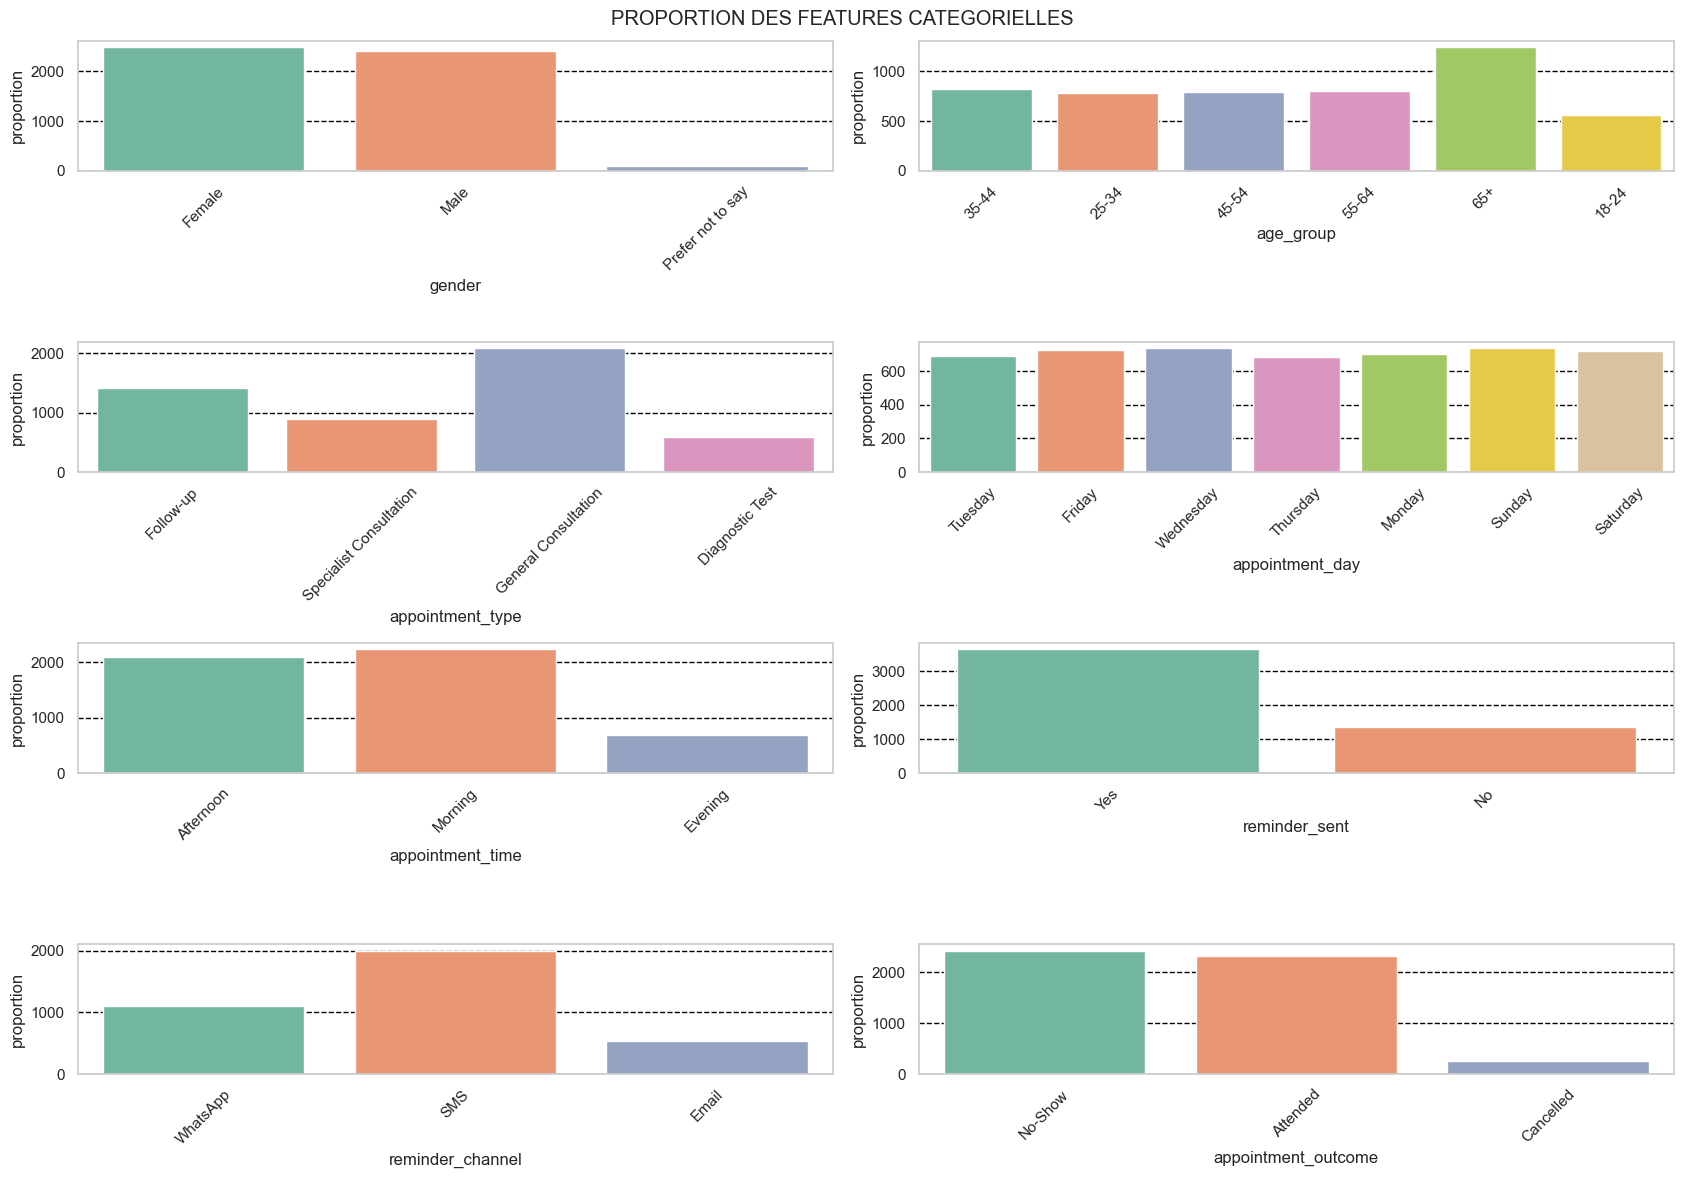

In [140]:
fig, ax = plt.subplots(4,2,  figsize=(17, 12))
ax = ax.flatten()
for index ,  val in enumerate(category):
    sns.countplot(
        data=data, 
        x=val, 
        hue=val, 
        palette="Set2", 
        legend=False, 
        ax=ax[index],
    )
    ax[index].set( ylabel="proportion")
    
    ax[index].tick_params(axis='x', rotation=45) 
    
plt.suptitle("PROPORTION OF CATEGORICAL FEATURES")
plt.tight_layout()
plt.savefig("../image/UNIVARIATE/barchart_univariate.png")
plt.show()

## Handling date Feature

In [141]:
data['booking_date'] = pd.to_datetime(data['booking_date'])
data['appointment_date'] =pd.to_datetime(data['appointment_date'])

In [142]:
## APPOINTMENT DATE ANALYSIS

In [143]:
appointment_month_by_year = pd.crosstab(data['appointment_date'].dt.month_name(), data['appointment_date'].dt.year)
appointment_month_by_year


appointment_date,2025,2026
appointment_date,,
April,278,274
August,291,0
December,260,0
February,266,290
January,270,250
July,267,0
June,295,290
March,302,270
May,272,280


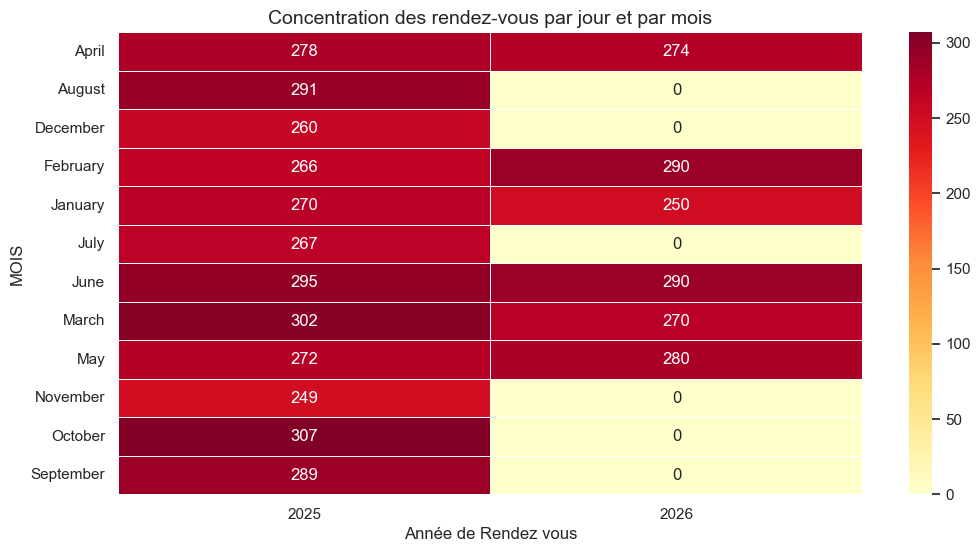

In [152]:
plt.figure(figsize=(12, 6))

# Creating the heatmap with the numbers displayed in the cells (annot=True)
sns.heatmap(appointment_month_by_year, annot=True, fmt="d", cmap="YlOrRd", linewidths=.5)

plt.title("Concentration of appointments by day and month", fontsize=14)
plt.xlabel("Appointment Year", fontsize=12)
plt.ylabel("MONTH", fontsize=12)
plt.savefig("../image/UNIVARIATE/distribution_appointments_month_by_year.png")
plt.show()

In [153]:
appointment_day_by_month =  pd.crosstab(data['appointment_date'].dt.day_name(), data['appointment_date'].dt.month_name())
appointment_day_by_month

appointment_date,April,August,December,February,January,July,June,March,May,November,October,September
appointment_date,,,,,,,,,,,,
Friday,67,55,34,81,110,31,73,59,93,36,57,32
Monday,90,39,46,74,65,35,99,82,67,34,33,37
Saturday,76,39,32,75,71,38,80,90,88,35,47,53
Sunday,74,52,32,97,64,32,87,91,83,47,41,37
Thursday,86,37,29,96,65,44,65,74,73,27,48,40
Tuesday,73,38,43,55,73,39,91,103,66,35,30,43
Wednesday,86,31,44,78,72,48,90,73,82,35,51,47


In [ ]:
plt.figure(figsize=(12, 6))

# Creating the heatmap with the numbers displayed in the cells (annot=True)
sns.heatmap(appointment_day_by_month, annot=True, fmt="d", cmap="YlOrRd", linewidths=.5)

plt.title("Concentration of appointments by day and month", fontsize=14)
plt.xlabel("Month", fontsize=12)
plt.ylabel("Day of Week", fontsize=12)
plt.savefig("../image/UNIVARIATE/distribution_appointments_day_by_month.png")

plt.show()

In [ ]:
## BOOKING DATE ANALYSIS 

In [ ]:
booking_month_by_year = pd.crosstab(data['booking_date'].dt.month_name(), data['booking_date'].dt.year)
booking_month_by_year


In [ ]:
plt.figure(figsize=(12, 6))

# Creating the heatmap with the numbers displayed in the cells (annot=True)
sns.heatmap(booking_month_by_year, annot=True, fmt="d", cmap="YlOrRd", linewidths=.5)

plt.title("Concentration of appointments by day and month", fontsize=14)
plt.xlabel("Appointment Year", fontsize=12)
plt.ylabel("MONTH", fontsize=12)
plt.savefig("../image/UNIVARIATE/distribution_booking_month_by_year.png")
plt.show()

In [ ]:
booking_day_by_month =  pd.crosstab(data['booking_date'].dt.day_name(), data['booking_date'].dt.month_name())
booking_day_by_month

In [ ]:
plt.figure(figsize=(12, 6))

# Creating the heatmap with the numbers displayed in the cells (annot=True)
sns.heatmap(booking_day_by_month, annot=True, fmt="d", cmap="YlOrRd", linewidths=.5)

plt.title("Concentration of appointments by day and month", fontsize=14)
plt.xlabel("Month", fontsize=12)
plt.ylabel("Day of Week", fontsize=12)
plt.savefig("../image/UNIVARIATE/distribution_booking_day_by_month.png")

plt.show()

## BIVARIATE ANALYSIS

## NUMERICAL&TARGET

In [ ]:
fig ,ax = plt.subplots(3,2, figsize=(16,9))
ax = ax.flatten()
for index, val in enumerate(num_features):
 sns.histplot(data=data , bins=30, x=val , hue="appointment_outcome",multiple="dodge", edgecolor="black" , palette=["#ff0054", "#386641","#f2e8cf"] , alpha=0.8 , kde=True , ax=ax[index] )
 ax[index].axvline(data[val].mean() , linestyle="--" , color="red", label=f"Mean:{data[val].mean():}")
 ax[index].axvline(data[val].median() , linestyle="--" , color="green", label=f"Median:{data[val].median()}")
 ax[index].set(title=f"{val}_histogram ", ylabel="Frequency" )
 ax[index].legend(loc="upper left")
for i in range( len(num_features) , len(ax)):
    fig.delaxes(ax[i])
plt.suptitle("DISTRIBUTION OF NUMERICAL FEATURES BY APPOINTMENT_OUTCOME")
plt.tight_layout()
plt.savefig("../image/BIVARIATE/histplot_bivariate.png")
plt.show()

In [ ]:
# interpretation

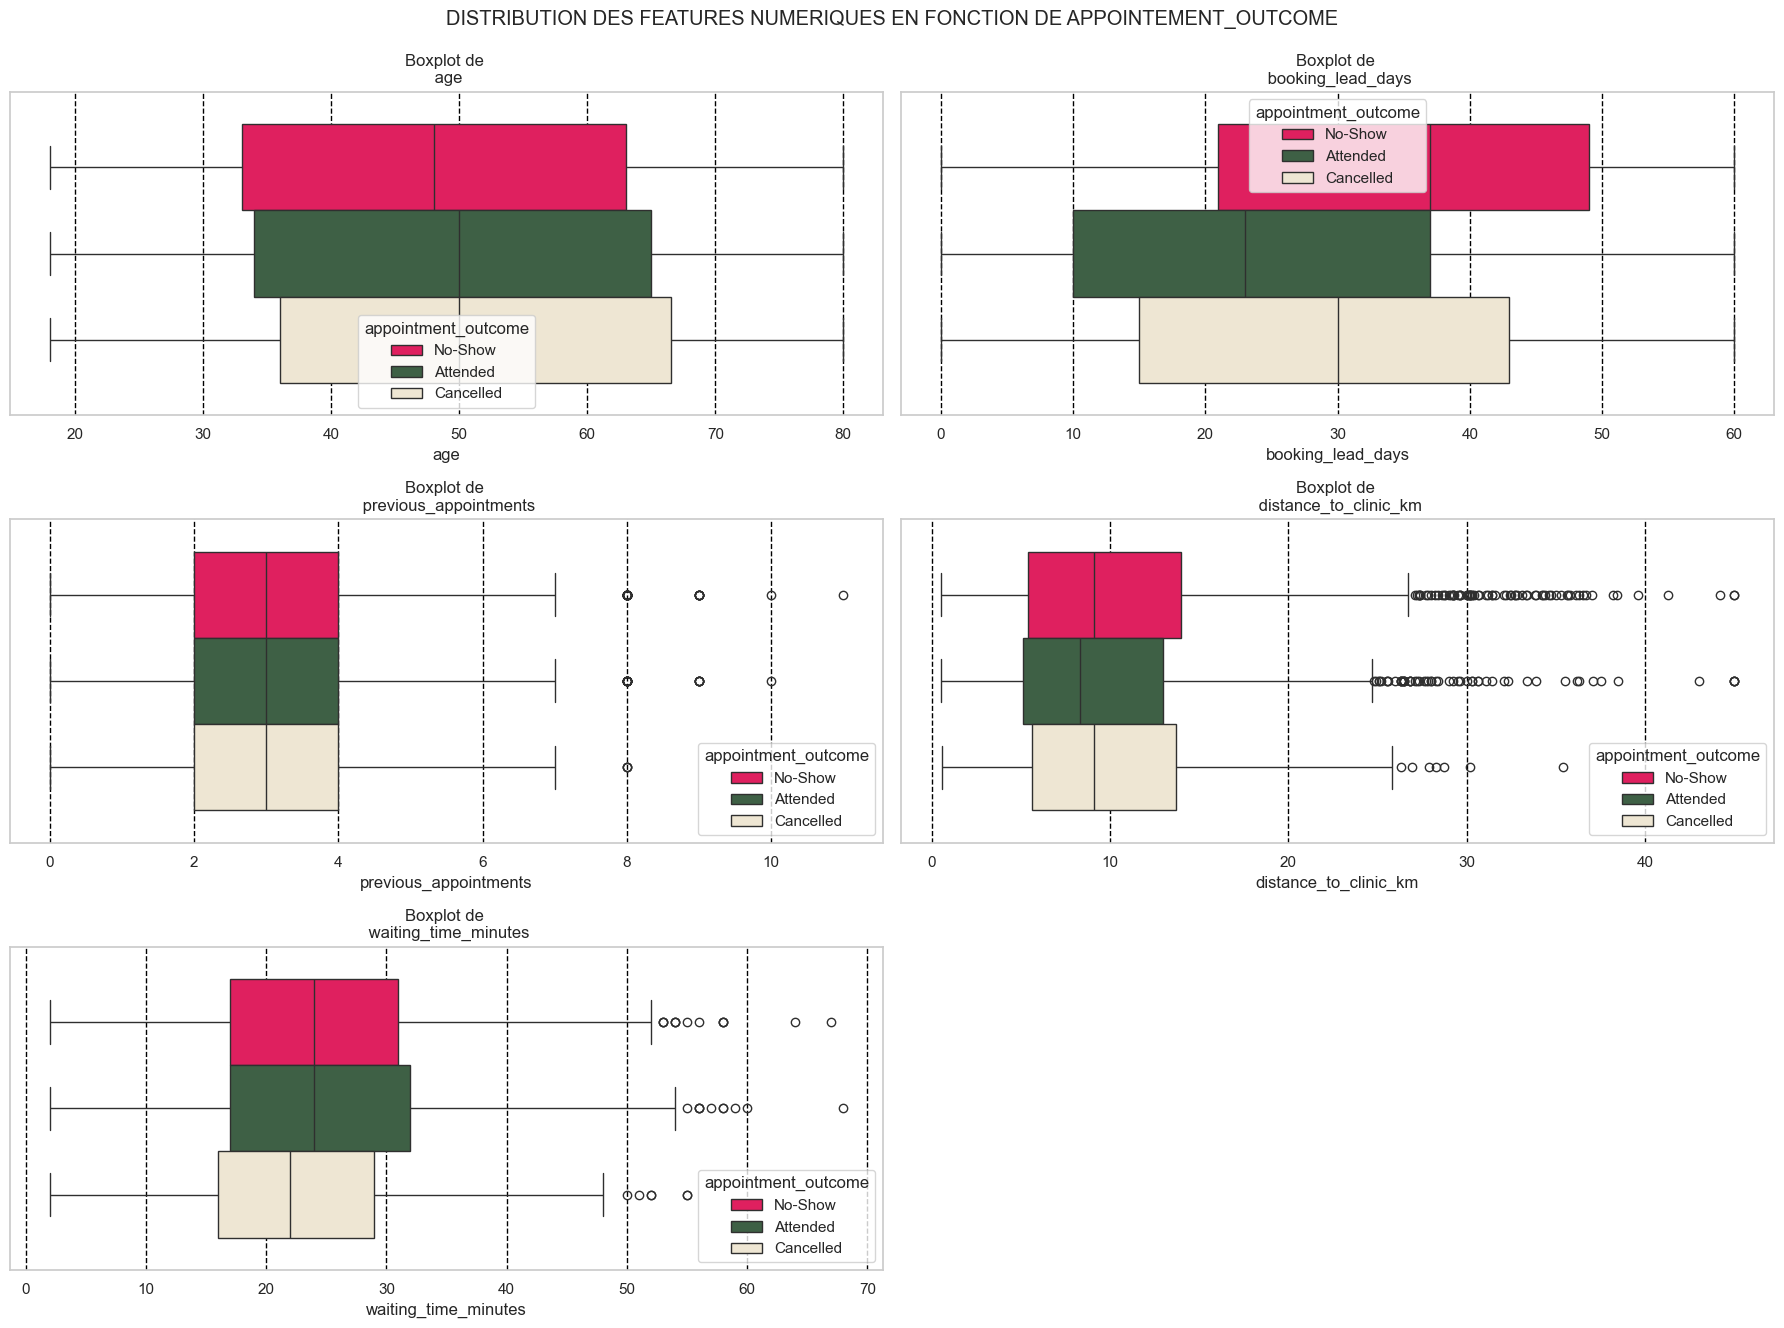

In [151]:
fig, ax = plt.subplots(3, 2, figsize=(18, 13))
ax = ax.flatten()

for index, val in enumerate(num_features):
    
    sns.boxplot(
        data=data,
        x=val,
        hue="appointment_outcome",
        palette=["#ff0054", "#386641","#f2e8cf"],
        ax=ax[index],
    )
    ax[index].set(title=f"Boxplot of \n {val}")

for i in range(len(num_features), len(ax)):
    fig.delaxes(ax[i])

plt.tight_layout()
plt.suptitle("DISTRIBUTION OF NUMERICAL FEATURES BY APPOINTMENT_OUTCOME", y=1.02)
plt.savefig("../image/BIVARIATE/boxplot.png")  
plt.show()

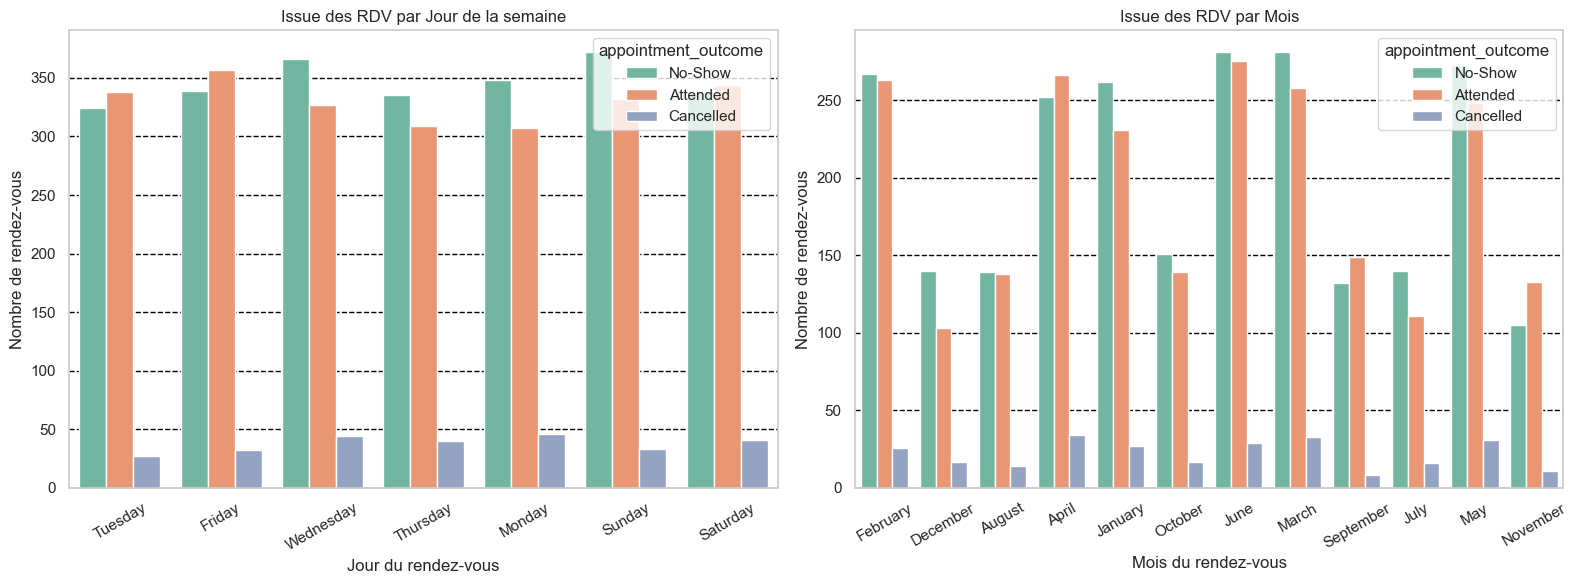

In [150]:

# Creating a single figure containing 2 side-by-side subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. First plot: Target by Day of the Week
sns.countplot(
    data=data,
    x=data['appointment_date'].dt.day_name(),
    hue='appointment_outcome',
    palette='Set2',
    ax=axes[0],
)
axes[0].set_title("Appointment Outcome by Day of the Week", fontsize=12)
axes[0].set_xlabel("Appointment Day")
axes[0].set_ylabel("Number of Appointments")
axes[0].tick_params(axis='x', rotation=30)

# 2. Second plot: Target by Appointment Month
sns.countplot(
    data=data,
    x=data['appointment_date'].dt.month_name(),
    hue='appointment_outcome',
    palette='Set2',
    ax=axes[1],
)
axes[1].set_title("Appointment Outcome by Month", fontsize=12)
axes[1].set_xlabel("Appointment Month")
axes[1].set_ylabel("Number of Appointments")
axes[1].tick_params(axis='x', rotation=30)

# Automatic adjustment to prevent text overlap
plt.tight_layout()
plt.savefig("../image/BIVARIATE/day_month_proportion_by_appointment_outcome.png")  
plt.show()

## Distance_to_clinic_km & Target

C:\Users\TINGOS\AppData\Local\Temp\ipykernel_15268\3007870481.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


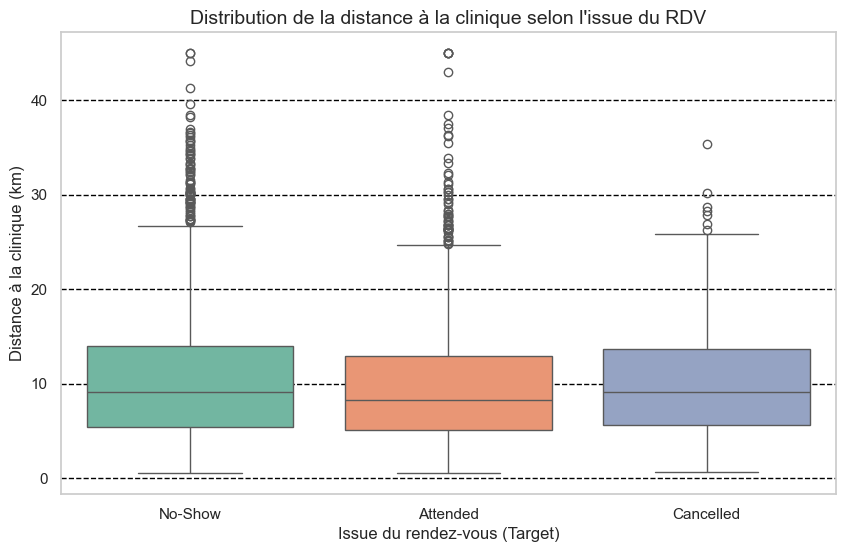

In [149]:
plt.figure(figsize=(10, 6))

# Boxplot to see the distance based on the target
sns.boxplot(
    data=data,
    x='appointment_outcome',
    y='distance_to_clinic_km',
    palette='Set2'
)

plt.title("Distribution of Distance to Clinic by Appointment Outcome", fontsize=14)
plt.xlabel("Appointment Outcome (Target)", fontsize=12)
plt.ylabel("Distance to Clinic (km)", fontsize=12)
plt.savefig("../image/BIVARIATE/clinic_distance_X_appointment_outcome.png")  
plt.show()

In [ ]:
## New_feature derived to 

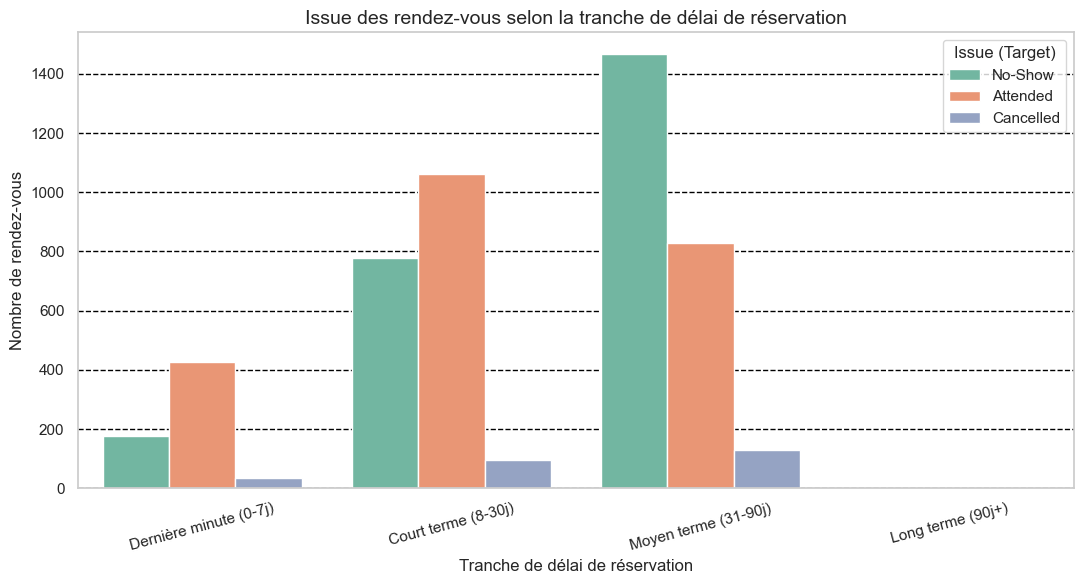

In [148]:

# 1. Recreate the segmentation on the fly for testing
bins = [0, 7, 30, 90, float('inf')]
labels = ['Last minute (0-7d)', 'Short term (8-30d)', 'Medium term (31-90d)', 'Long term (90d+)']
lead_cat_temp = pd.cut(data['booking_lead_days'], bins=bins, labels=labels, include_lowest=True)

# 2. Plot the countplot passing this temporary series to the x axis
plt.figure(figsize=(11, 6))
sns.countplot(
    x=lead_cat_temp,
    hue=data['appointment_outcome'],
    palette='Set2'
)

plt.title("Appointment Outcome by Booking Lead Time Bracket", fontsize=14)
plt.xlabel("Booking Lead Time Bracket", fontsize=12)
plt.ylabel("Number of Appointments", fontsize=12)
plt.xticks(rotation=15)
plt.legend(title="Outcome (Target)")
plt.savefig("../image/BIVARIATE/booking_lead_time_X_appointment_outcome.png")  
plt.tight_layout()
plt.show()

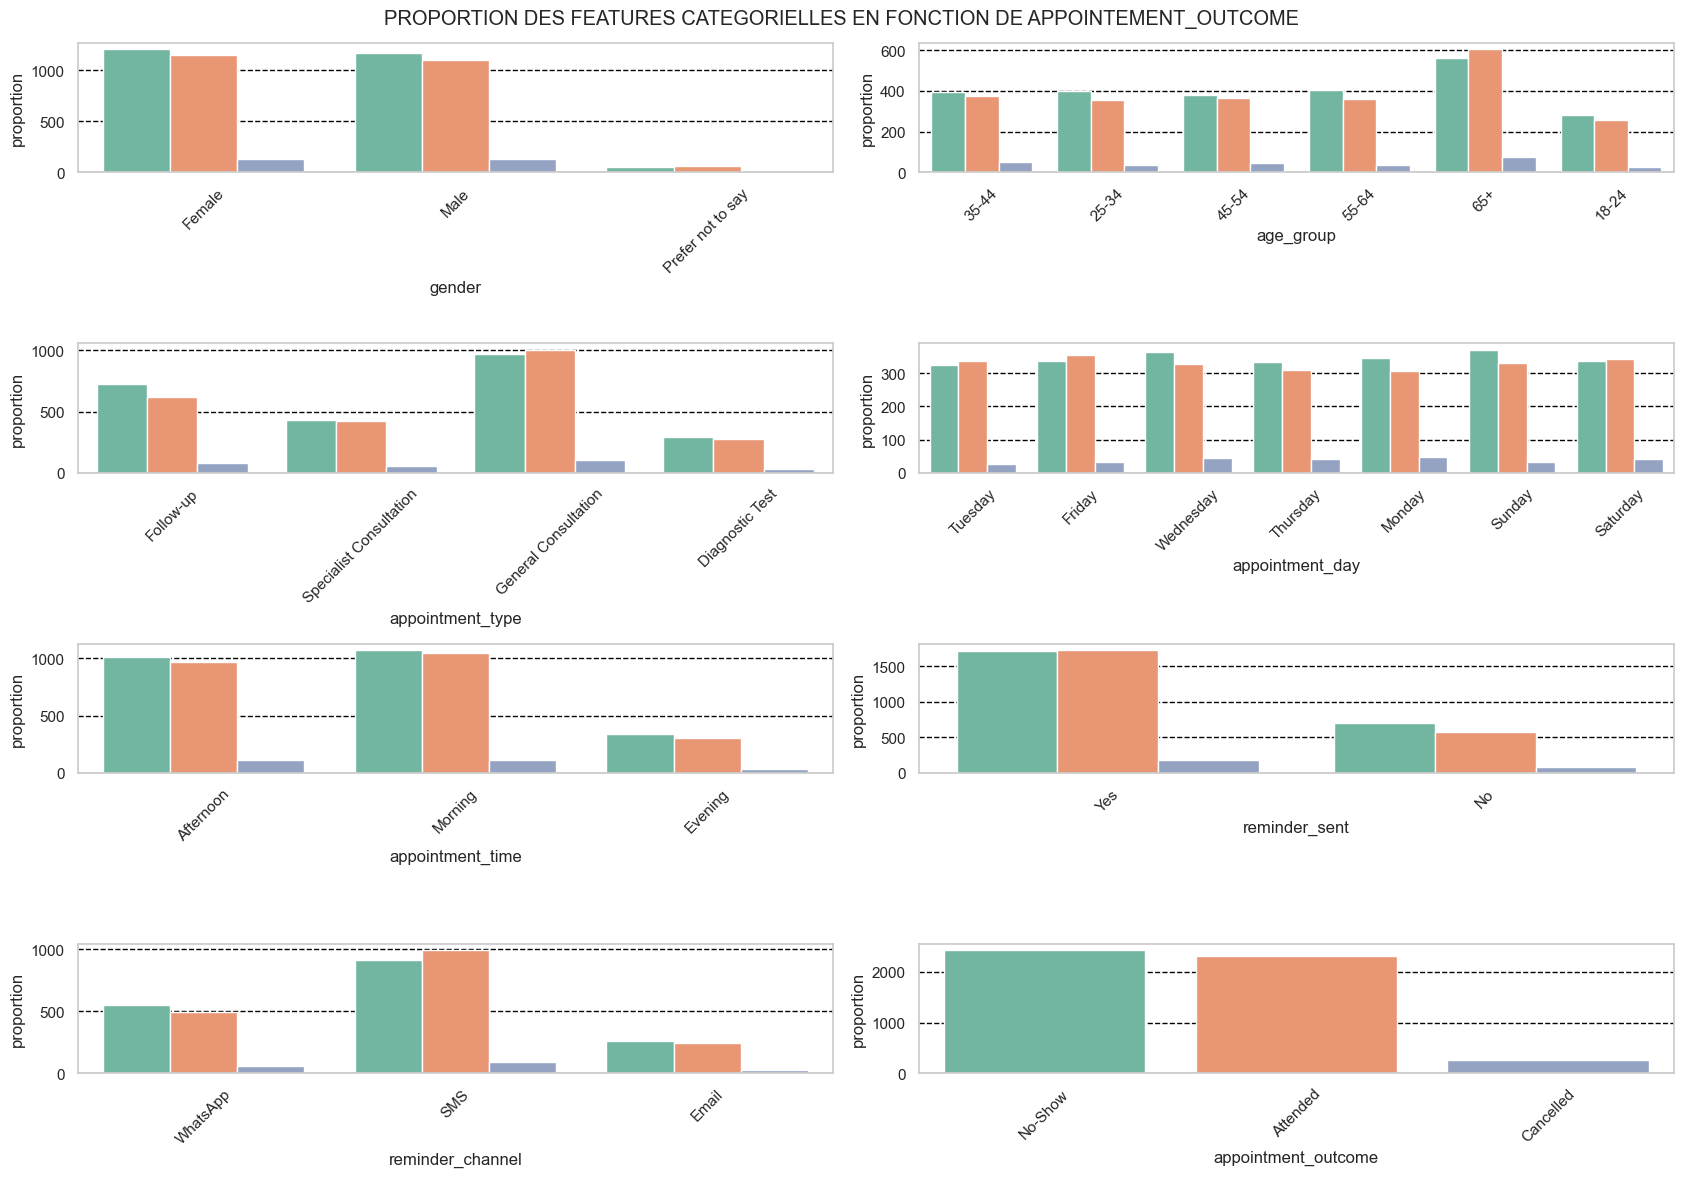

In [147]:
fig, ax = plt.subplots(4,2,  figsize=(17, 12))
ax=ax.flatten()
for index ,  val in enumerate(category):
    sns.countplot(
        data=data, 
        x=val, 
        hue="appointment_outcome", 
        palette="Set2", 
        legend=False, 
        ax=ax[index],
    )
    ax[index].set( ylabel="proportion")
    
    ax[index].tick_params(axis='x', rotation=45) 
    
plt.suptitle("PROPORTION OF CATEGORICAL FEATURES BY APPOINTMENT_OUTCOME")
plt.tight_layout()
plt.savefig("../image/BIVARIATE/barchart_bivariate.png")
plt.show()

## DISPERSION AND CORRELATION ANALYSIS

In [ ]:
data["appointment_outcome"] = data["appointment_outcome"].map({
    'Attended': 1, 
    'No-Show': 0, 
    'Cancelled': 2  # Adjust the numeric values according to your business logic
})

In [1]:
corr_tion =data.select_dtypes(include="number")
corr = corr_tion.corr()
mask = np.triu(np.ones_like(corr , dtype=bool))
plt.figure(figsize=(11,7))
sns.heatmap(corr , mask=mask , fmt=".2f" , annot=True , cmap="coolwarm" )
plt.savefig("../image/CORRELATION/heatmap.png")

NameError: name 'data' is not defined

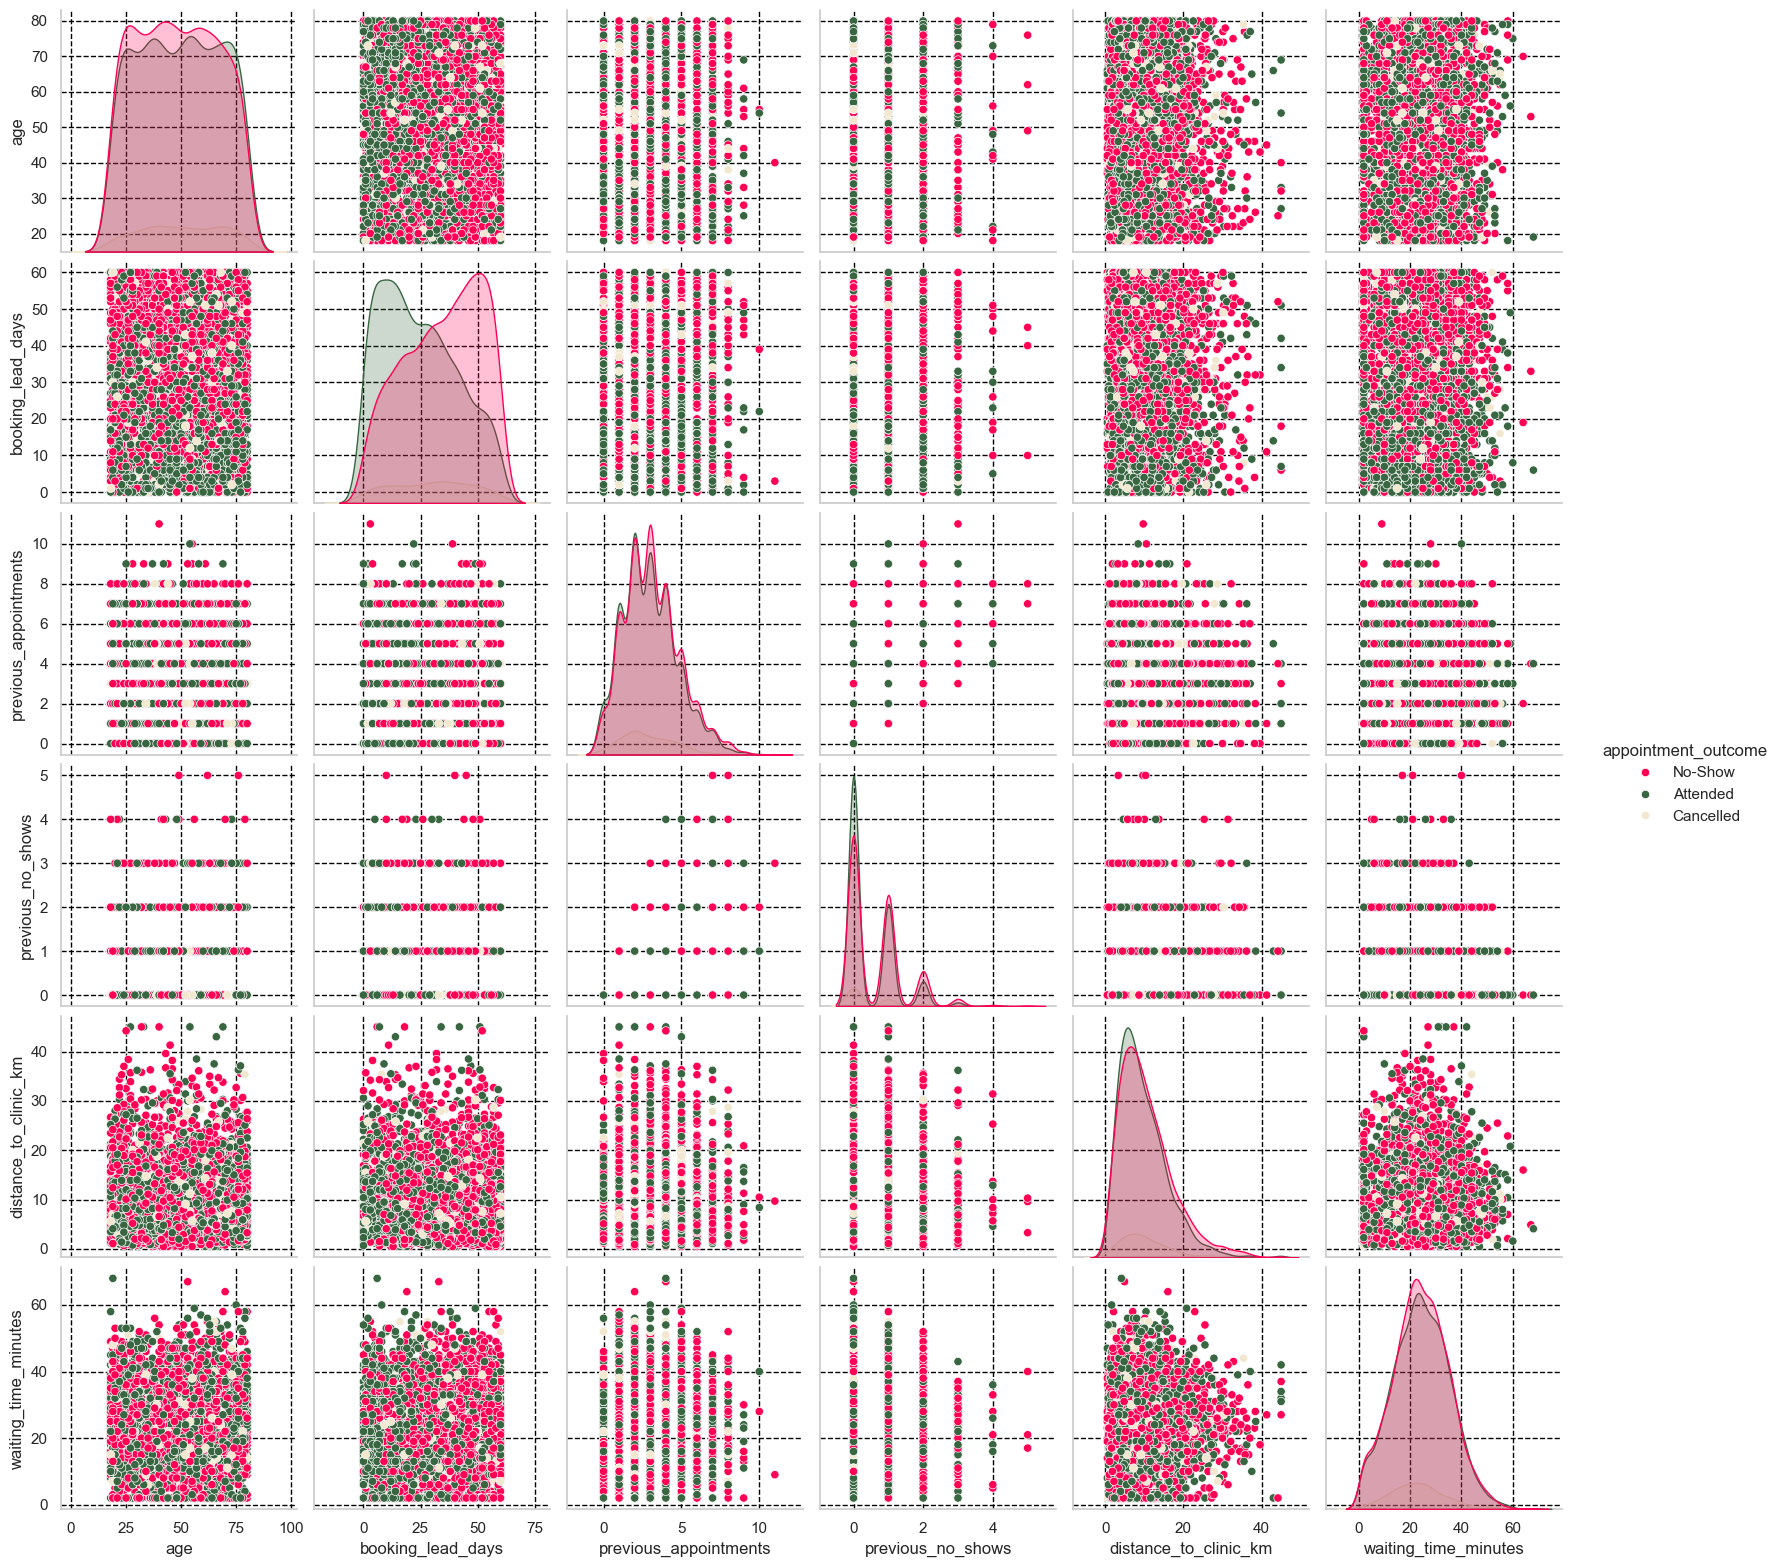

In [145]:
g = sns.pairplot(data=data , hue="appointment_outcome" , palette=["#ff0054", "#386641","#f2e8cf"] , dropna=True)
g.fig.set_size_inches(18,16)
g.fig.savefig("../image/CORRELATION/pairplot.png")
plt.show()

====================================================================
EXPLORATORY DATA ANALYSIS (EDA) - STRUCTURED INTERPRETATION REPORT
====================================================================
1. TARGET VARIABLE ANALYSIS & CLASS DISTRIBUTION
- Observation: The target variable (appointment_outcome) is composed of three modalities: No-Show (~48%), Attended (~46%), and Cancelled (~6%).
- Interpretation: The distribution reveals a near-even split between attended appointments and no-shows, but the "Cancelled" class represents a minor fraction (6%). Treating cancellations as an independent third class risks introducing operational noise during model training. Consequently, merging cancellations and no-shows into a binary classification approach (Attended vs. Not Attended) is validated to stabilize learning.
2. UNIVARIATE ANALYSIS (NUMERICAL & CATEGORICAL FEATURES)
- Observation:
  * Numerical features (age, booking_lead_days, previous_appointments, distance_to_clinic_km, waiting_time_minutes) exhibit broad dispersions and realistic distributions without severe corruption, though specific outliers exist in distance and historical counts.
  * Categorical features (gender, age_group, appointment_type, appointment_day, appointment_time, reminder_sent, reminder_channel) show balanced overall representation. However, a critical data quality anomaly was detected: appointments are scheduled on Sundays, which directly contradicts the clinic's official operating rules stating that the facility is closed on Sundays.
- Interpretation: The presence of Sunday appointments confirms the synthetic nature of the dataset, where generation rules were imperfectly enforced. Overall, the univariate spreads indicate that standard scaling and outlier-robust tree models will handle the numerical inputs effectively.
3. CORRELATION & LINEARITY ASSESSMENT
- Observation: The correlation matrix displays near-zero linear coefficients across features (except for a logical relation between past appointments and past no-shows), and the pairplots demonstrate high data dispersion without clear linear separation boundaries.
- Interpretation: There is a total absence of strong linear relationships between predictors and the target. Traditional linear models (such as Logistic Regression) are inadequate for this dataset, justifying a direct transition to non-linear, tree-based machine learning algorithms (e.g., Random Forest, XGBoost) capable of capturing complex decision thresholds.
4. BIVARIATE ANALYSIS & BEHAVIORAL INSIGHTS
- Observation:
  * Booking Lead Time: Segmenting booking_lead_days into time windows (Short-term vs. Medium/Long-term) reveals a dramatic behavioral shift in appointment outcomes. Short-notice bookings (0–7 days) show high attendance, while medium-to-long-term bookings (31–90 days) experience a massive surge in No-Shows.
  * Auxiliary Features: Bivariate plots for geographic distance, gender, and reminder channels show uniform distributions across outcome classes.
- Interpretation: Booking lead time stands out as the single most critical predictive feature in the dataset. Patients who schedule weeks or months in advance display a significantly higher attrition risk. In contrast, auxiliary variables like distance act as weak standalone predictors, meaning model performance will heavily rely on temporal and historical behavioral features.
5. CONCLUSION FOR MODELING PHASE
- The hierarchical EDA successfully validated the target's class constraints, identified data quality artifacts, isolated key non-linear behavioral predictors, and established a clear roadmap for data preprocessing, class binning, and non-linear model training.